# Full-Covariance ADF Accuracy Check for a 3-Layer ReLU MLP

This notebook turns the concrete ADF walkthrough into an executable check. We build a small 3-layer MLP with a non-zero-mean Gaussian input and a full input covariance, propagate moments analytically with full-covariance ADF, and compare the predicted output expectation and covariance against Monte Carlo samples.

For the one-hidden-layer, linear-output case, full-covariance ADF is not merely an approximation for the first two output moments: the input-to-hidden Gaussian is exact, the ReLU moments are matched exactly, and the final linear layer preserves those moments exactly. Any remaining disagreement should mostly be Monte Carlo sampling error or numerical tolerance. The optional last section shows where full covariance starts affecting downstream expected activations when another ReLU is applied, which is closer to the deep WHest setting.

## 1. Import Libraries and Configure Plotting

We use SciPy for the standard normal PDF/CDF and bivariate normal CDF, NumPy for moment propagation and sampling, and Matplotlib for diagnostics.

If this import cell fails in the repo-managed environment, install the notebook-only plotting/math helpers in your chosen kernel environment (`scipy` and `matplotlib`). The starter kit runtime dependencies are intentionally minimal, while this exploratory notebook mirrors `sample_data_viz.ipynb` and uses the scientific plotting stack.

In [ ]:
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm

try:
    import whestbench as wb
except ImportError:
    wb = None

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(42)

/Users/yangxinyuxie/Desktop/White-Box Estimation/whest-starterkit/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define a 3-Layer ReLU MLP and Full-Covariance Gaussian Input

The toy network follows the column-vector convention from the derivation:

$$z_1 = W_1 x_0 + b_1, \quad x_1 = \mathrm{ReLU}(z_1), \quad z_2 = W_2 x_1 + b_2.$$

The input has a non-zero mean and a dense positive-definite covariance matrix.

In [2]:
D0, D1, D2 = 5, 9, 4

W1 = rng.normal(scale=0.75 / np.sqrt(D0), size=(D1, D0))
b1 = rng.normal(loc=0.15, scale=0.35, size=D1)
W2 = rng.normal(scale=0.65 / np.sqrt(D1), size=(D2, D1))
b2 = rng.normal(loc=-0.05, scale=0.20, size=D2)

mu0 = np.linspace(-0.8, 0.8, D0)
A = rng.normal(size=(D0, D0))
Sigma0 = A @ A.T
Sigma0 = Sigma0 / np.sqrt(np.outer(np.diag(Sigma0), np.diag(Sigma0)))
std0 = np.linspace(0.55, 1.35, D0)
Sigma0 = Sigma0 * np.outer(std0, std0)

print("Shapes")
print(f"  W1 {W1.shape}, b1 {b1.shape}")
print(f"  W2 {W2.shape}, b2 {b2.shape}")
print(f"  mu0 {mu0.shape}, Sigma0 {Sigma0.shape}")
print(f"min eig(Sigma0) = {np.linalg.eigvalsh(Sigma0).min():.3e}")

Shapes
  W1 (9, 5), b1 (9,)
  W2 (4, 9), b2 (4,)
  mu0 (5,), Sigma0 (5, 5)
min eig(Sigma0) = 8.461e-05


## 3. Implement Linear Gaussian Moment Propagation

Affine maps preserve Gaussianity exactly. This helper also symmetrizes the covariance after matrix multiplication to damp tiny floating-point asymmetries.

In [3]:
def symmetrize(Sigma):
    return 0.5 * (Sigma + Sigma.T)


def affine_gaussian_moments(mu, Sigma, W, b):
    """Propagate N(mu, Sigma) through z = W @ x + b."""
    mu = np.asarray(mu, dtype=np.float64)
    Sigma = np.asarray(Sigma, dtype=np.float64)
    W = np.asarray(W, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    assert W.shape[1] == mu.shape[0]
    assert Sigma.shape == (mu.shape[0], mu.shape[0])
    assert b.shape == (W.shape[0],)

    mu_z = W @ mu + b
    Sigma_z = symmetrize(W @ Sigma @ W.T)
    return mu_z, Sigma_z

## 4. Implement ReLU ADF Mean and Full-Covariance Moment Matching

For each neuron, the matched mean and variance use the closed-form univariate Gaussian-ReLU moments.

For each pair of hidden neurons, we compute

$$E[\max(0, z_i)\max(0, z_j)]$$

from the corresponding bivariate normal. The implementation below uses the standard normal PDF/CDF, the bivariate normal CDF for the shared positive orthant probability, and the closed-form bivariate Gaussian-ReLU kernel terms.

In [ ]:
def relu_univariate_moments(mu, var, eps=1e-12):
    mu = np.asarray(mu, dtype=np.float64)
    var = np.maximum(np.asarray(var, dtype=np.float64), eps)
    sigma = np.sqrt(var)
    alpha = mu / sigma
    Phi = norm.cdf(alpha)
    phi = norm.pdf(alpha)

    mean = mu * Phi + sigma * phi
    second = (mu * mu + var) * Phi + mu * sigma * phi
    variance = np.maximum(second - mean * mean, 0.0)
    return mean, variance, second


def bivar_standard_pdf(x, y, rho):
    rho = float(np.clip(rho, -0.999999, 0.999999))
    denom = 2.0 * np.pi * np.sqrt(1.0 - rho * rho)
    quad = (x * x - 2.0 * rho * x * y + y * y) / (2.0 * (1.0 - rho * rho))
    return np.exp(-quad) / denom


def relu_pair_cross_moment(mu_i, mu_j, var_i, var_j, cov_ij, eps=1e-12):
    sigma_i = float(np.sqrt(max(var_i, eps)))
    sigma_j = float(np.sqrt(max(var_j, eps)))
    alpha_i = float(mu_i / sigma_i)
    alpha_j = float(mu_j / sigma_j)
    rho = float(np.clip(cov_ij / (sigma_i * sigma_j), -0.999999, 0.999999))

    s = np.sqrt(1.0 - rho * rho)
    Phi2 = multivariate_normal.cdf(
        [alpha_i, alpha_j],
        mean=[0.0, 0.0],
        cov=[[1.0, rho], [rho, 1.0]],
    )
    phi_i = norm.pdf(alpha_i)
    phi_j = norm.pdf(alpha_j)
    Phi_i_given_j = norm.cdf((alpha_i - rho * alpha_j) / s)
    Phi_j_given_i = norm.cdf((alpha_j - rho * alpha_i) / s)

    Eu = phi_i * Phi_j_given_i + rho * phi_j * Phi_i_given_j
    Ev = phi_j * Phi_i_given_j + rho * phi_i * Phi_j_given_i
    Euv = rho * Phi2 + (1.0 - rho * rho) * bivar_standard_pdf(alpha_i, alpha_j, rho)

    return (
        mu_i * mu_j * Phi2
        + mu_i * sigma_j * Ev
        + mu_j * sigma_i * Eu
        + sigma_i * sigma_j * Euv
    )


def relu_adf_full_moments(mu_z, Sigma_z):
    mu_z = np.asarray(mu_z, dtype=np.float64)
    Sigma_z = symmetrize(np.asarray(Sigma_z, dtype=np.float64))
    dim = mu_z.shape[0]
    var_z = np.maximum(np.diag(Sigma_z), 1e-12)

    mu_relu, _, second_relu = relu_univariate_moments(mu_z, var_z)
    second_matrix = np.empty((dim, dim), dtype=np.float64)
    np.fill_diagonal(second_matrix, second_relu)

    for i in range(dim):
        for j in range(i + 1, dim):
            cross = relu_pair_cross_moment(mu_z[i], mu_z[j], var_z[i], var_z[j], Sigma_z[i, j])
            second_matrix[i, j] = cross
            second_matrix[j, i] = cross

    Sigma_relu = symmetrize(second_matrix - np.outer(mu_relu, mu_relu))
    diag = np.maximum(np.diag(Sigma_relu), 0.0)
    Sigma_relu[np.diag_indices(dim)] = diag
    return mu_relu, Sigma_relu, second_matrix

## 5. Run the Full-Covariance ADF Forward Pass

This is the direct implementation of the three-step derivation:

1. Linear Gaussian propagation into the hidden pre-activation.
2. Full-covariance ReLU moment matching.
3. Linear Gaussian propagation into the output.

In [5]:
mu_z1, Sigma_z1 = affine_gaussian_moments(mu0, Sigma0, W1, b1)
mu1_adf, Sigma1_adf, E_x1x1_adf = relu_adf_full_moments(mu_z1, Sigma_z1)
mu_out_adf, Sigma_out_adf = affine_gaussian_moments(mu1_adf, Sigma1_adf, W2, b2)

print("Hidden pre-activation")
print(f"  mu_z1 shape: {mu_z1.shape}")
print(f"  Sigma_z1 shape: {Sigma_z1.shape}")
print("Hidden post-ReLU matched Gaussian")
print(f"  mu1_adf shape: {mu1_adf.shape}")
print(f"  Sigma1_adf min eig: {np.linalg.eigvalsh(Sigma1_adf).min():.3e}")
print("Output ADF moments")
print(f"  mu_out_adf = {np.round(mu_out_adf, 6)}")
print(f"  output variances = {np.round(np.diag(Sigma_out_adf), 6)}")

Hidden pre-activation
  mu_z1 shape: (9,)
  Sigma_z1 shape: (9, 9)
Hidden post-ReLU matched Gaussian
  mu1_adf shape: (9,)
  Sigma1_adf min eig: -8.324e-02
Output ADF moments
  mu_out_adf = [ 0.146968  0.116917 -0.02563  -0.396133]
  output variances = [0.052855 0.011054 0.022563 0.052668]


## 6. Run a Monte Carlo Reference Forward Pass

The reference samples from the original Gaussian input and runs the exact nonlinear network. Increase `N_MC` if you want a tighter reference, at the cost of runtime.

In [6]:
def exact_forward(samples, W1, b1, W2, b2):
    hidden = np.maximum(samples @ W1.T + b1, 0.0)
    out = hidden @ W2.T + b2
    return hidden, out


def monte_carlo_reference(n_samples, seed=0):
    local_rng = np.random.default_rng(seed)
    x = local_rng.multivariate_normal(mu0, Sigma0, size=n_samples, method="svd")
    hidden, out = exact_forward(x, W1, b1, W2, b2)
    return {
        "hidden_mean": hidden.mean(axis=0),
        "hidden_cov": np.cov(hidden, rowvar=False),
        "out_mean": out.mean(axis=0),
        "out_cov": np.cov(out, rowvar=False),
        "out_stderr": out.std(axis=0, ddof=1) / np.sqrt(n_samples),
    }

N_MC = 300_000
mc = monte_carlo_reference(N_MC, seed=123)
print(f"Monte Carlo samples: {N_MC:,}")
print(f"MC output mean = {np.round(mc['out_mean'], 6)}")
print(f"MC output standard error = {np.round(mc['out_stderr'], 6)}")

Monte Carlo samples: 300,000
MC output mean = [ 0.147795  0.117489 -0.02579  -0.397004]
MC output standard error = [0.000409 0.000241 0.000279 0.000404]


## 7. Compare Output Mean and Covariance Errors

For this 3-layer architecture, the ADF output mean and covariance should agree with the Monte Carlo estimates within sampling error. We report mean-vector errors, covariance Frobenius errors, diagonal variance errors, and correlation-matrix errors.

In [7]:
def corr_from_cov(Sigma, eps=1e-12):
    diag = np.maximum(np.diag(Sigma), eps)
    denom = np.sqrt(np.outer(diag, diag))
    return np.divide(Sigma, denom, out=np.zeros_like(Sigma), where=denom > 0)


def summarize_errors(mu_hat, Sigma_hat, mu_ref, Sigma_ref, label="ADF vs MC"):
    mean_err = mu_hat - mu_ref
    cov_err = Sigma_hat - Sigma_ref
    diag_err = np.diag(Sigma_hat) - np.diag(Sigma_ref)
    corr_err = corr_from_cov(Sigma_hat) - corr_from_cov(Sigma_ref)
    denom = np.maximum(np.abs(mu_ref), 1e-12)

    rows = [
        ("mean RMSE", np.sqrt(np.mean(mean_err ** 2))),
        ("mean max abs", np.max(np.abs(mean_err))),
        ("mean median relative abs", np.median(np.abs(mean_err) / denom)),
        ("cov Frobenius", np.linalg.norm(cov_err, ord="fro")),
        ("cov relative Frobenius", np.linalg.norm(cov_err, ord="fro") / np.linalg.norm(Sigma_ref, ord="fro")),
        ("variance RMSE", np.sqrt(np.mean(diag_err ** 2))),
        ("correlation Frobenius", np.linalg.norm(corr_err, ord="fro")),
    ]
    print(label)
    for name, value in rows:
        print(f"  {name:26s}: {value:.6e}")
    return rows

error_rows = summarize_errors(mu_out_adf, Sigma_out_adf, mc["out_mean"], mc["out_cov"])
print("\nOutput-wise mean error")
for k, (adf, ref, se) in enumerate(zip(mu_out_adf, mc["out_mean"], mc["out_stderr"])):
    z = (adf - ref) / se
    print(f"  output {k}: ADF={adf:+.6f}  MC={ref:+.6f}  err={adf-ref:+.3e}  err/MC_SE={z:+.2f}")

ADF vs MC
  mean RMSE                 : 6.698449e-04
  mean max abs              : 8.706837e-04
  mean median relative abs  : 5.231577e-03
  cov Frobenius             : 1.332799e-02
  cov relative Frobenius    : 1.360478e-01
  variance RMSE             : 3.988636e-03
  correlation Frobenius     : 4.543868e-01

Output-wise mean error
  output 0: ADF=+0.146968  MC=+0.147795  err=-8.273e-04  err/MC_SE=-2.02
  output 1: ADF=+0.116917  MC=+0.117489  err=-5.716e-04  err/MC_SE=-2.37
  output 2: ADF=-0.025630  MC=-0.025790  err=+1.596e-04  err/MC_SE=+0.57
  output 3: ADF=-0.396133  MC=-0.397004  err=+8.707e-04  err/MC_SE=+2.16


## 8. Visualize ADF vs Monte Carlo Output Expectations

The scatter should sit on the diagonal. Error bars show one Monte Carlo standard error for each output coordinate.

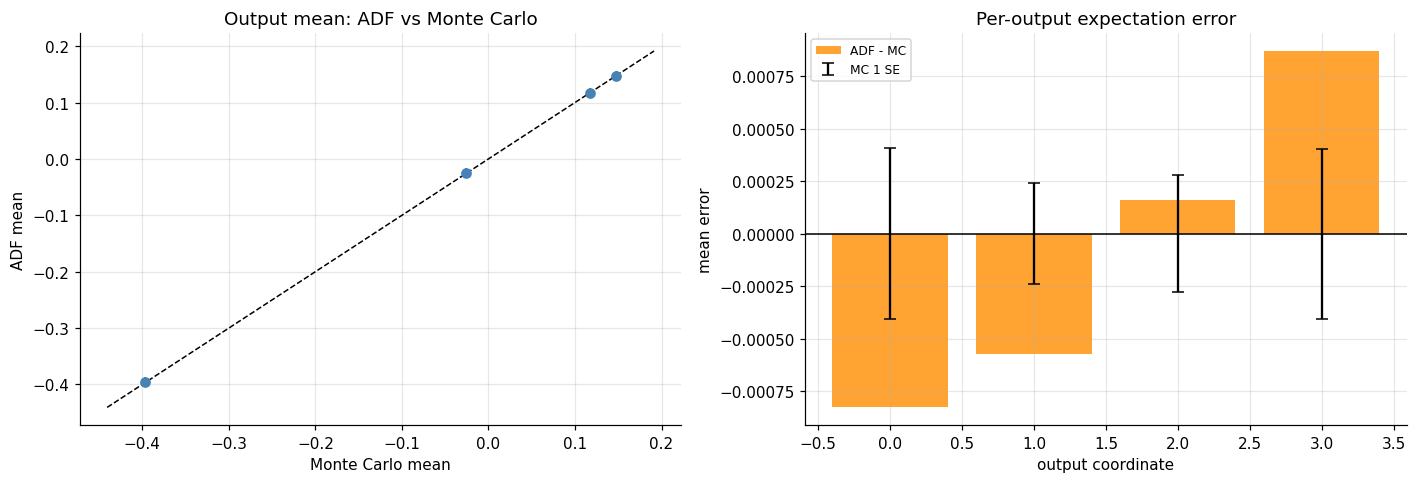

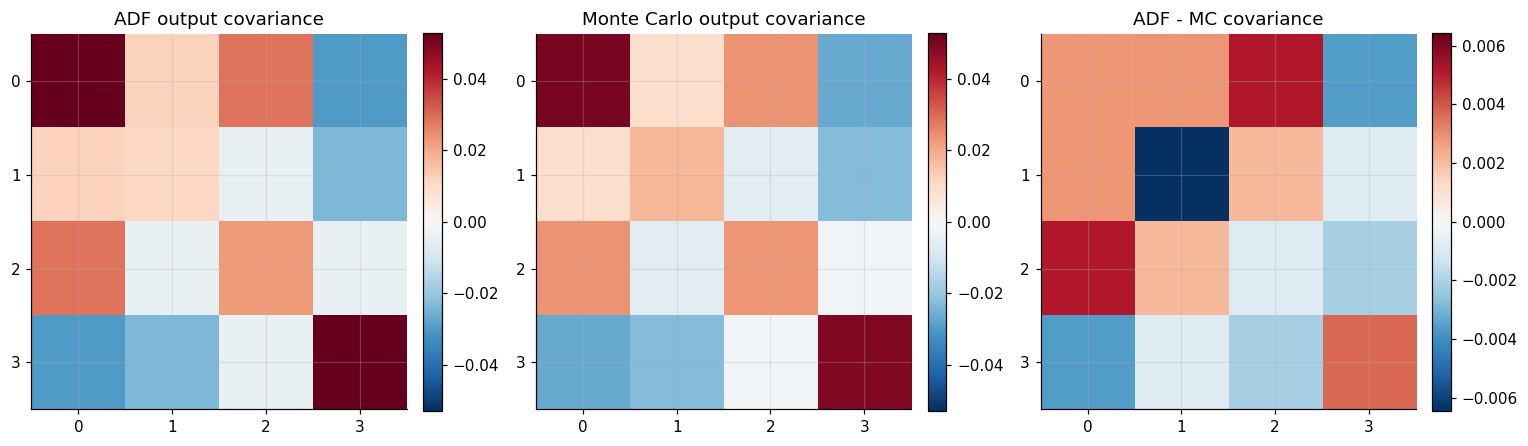

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.errorbar(mc["out_mean"], mu_out_adf, xerr=mc["out_stderr"], fmt="o", capsize=3, color="steelblue")
lo = min(mc["out_mean"].min(), mu_out_adf.min())
hi = max(mc["out_mean"].max(), mu_out_adf.max())
pad = 0.08 * max(hi - lo, 1e-6)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1)
ax.set(title="Output mean: ADF vs Monte Carlo", xlabel="Monte Carlo mean", ylabel="ADF mean")

ax = axes[1]
coords = np.arange(D2)
ax.bar(coords, mu_out_adf - mc["out_mean"], color="darkorange", alpha=0.8, label="ADF - MC")
ax.errorbar(coords, np.zeros(D2), yerr=mc["out_stderr"], fmt="none", color="k", capsize=4, label="MC 1 SE")
ax.axhline(0, color="k", lw=1)
ax.set(title="Per-output expectation error", xlabel="output coordinate", ylabel="mean error")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
vmax = max(np.abs(Sigma_out_adf).max(), np.abs(mc["out_cov"]).max())
for ax, mat, title in [
    (axes[0], Sigma_out_adf, "ADF output covariance"),
    (axes[1], mc["out_cov"], "Monte Carlo output covariance"),
    (axes[2], Sigma_out_adf - mc["out_cov"], "ADF - MC covariance"),
]:
    scale = vmax if "ADF - MC" not in title else max(np.abs(mat).max(), 1e-12)
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set_title(title)
    ax.set_xticks(range(D2)); ax.set_yticks(range(D2))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 9. Test Accuracy Across Monte Carlo Sample Sizes

Here we rerun the Monte Carlo estimator for increasing sample counts and compare each empirical reference to the fixed ADF result. For the one-hidden-layer linear-output network, the mean error should shrink like sampling noise as `n` grows.

n=  1,000  mean_RMSE=3.937e-03  avg_MC_SE=5.873e-03  cov_rel_F=1.433e-01
n=  3,000  mean_RMSE=3.892e-03  avg_MC_SE=3.448e-03  cov_rel_F=1.359e-01
n= 10,000  mean_RMSE=1.067e-03  avg_MC_SE=1.859e-03  cov_rel_F=1.335e-01
n= 30,000  mean_RMSE=7.876e-04  avg_MC_SE=1.080e-03  cov_rel_F=1.214e-01
n=100,000  mean_RMSE=2.816e-04  avg_MC_SE=5.894e-04  cov_rel_F=1.263e-01
n=300,000  mean_RMSE=3.187e-04  avg_MC_SE=3.414e-04  cov_rel_F=1.236e-01


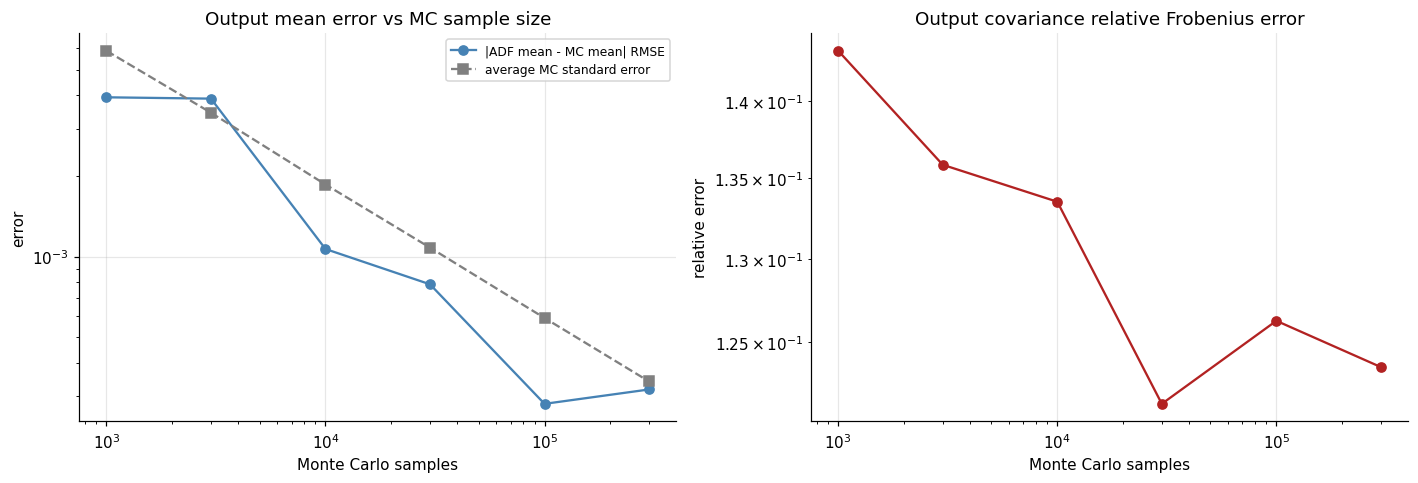

In [9]:
sample_sizes = np.array([1_000, 3_000, 10_000, 30_000, 100_000, 300_000])
conv = []
for n_samp in sample_sizes:
    ref = monte_carlo_reference(int(n_samp), seed=10 + int(n_samp))
    mean_rmse = np.sqrt(np.mean((mu_out_adf - ref["out_mean"]) ** 2))
    cov_rel = np.linalg.norm(Sigma_out_adf - ref["out_cov"], ord="fro") / np.linalg.norm(Sigma_out_adf, ord="fro")
    avg_se = np.sqrt(np.mean(ref["out_stderr"] ** 2))
    conv.append((n_samp, mean_rmse, cov_rel, avg_se))
    print(f"n={n_samp:>7,}  mean_RMSE={mean_rmse:.3e}  avg_MC_SE={avg_se:.3e}  cov_rel_F={cov_rel:.3e}")

conv = np.array(conv, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(conv[:, 0], conv[:, 1], "o-", color="steelblue", label="|ADF mean - MC mean| RMSE")
axes[0].loglog(conv[:, 0], conv[:, 3], "s--", color="gray", label="average MC standard error")
axes[0].set(title="Output mean error vs MC sample size", xlabel="Monte Carlo samples", ylabel="error")
axes[0].legend(fontsize=8)

axes[1].loglog(conv[:, 0], conv[:, 2], "o-", color="firebrick")
axes[1].set(title="Output covariance relative Frobenius error", xlabel="Monte Carlo samples", ylabel="relative error")

plt.tight_layout()
plt.show()

## 10. Stress Test ADF Across Weight Scales and Input Correlations

This sweep varies weight scale, input covariance strength, hidden width, and input mean magnitude. Because this network has only one ReLU layer followed by a linear output, full-covariance ADF remains moment-exact; larger errors here usually indicate that the Monte Carlo reference needs more samples or the numerical CDFs are being pushed into a harder regime.

In [10]:
@dataclass
class TrialResult:
    weight_scale: float
    corr_strength: float
    hidden_width: int
    mean_magnitude: float
    mean_rmse: float
    mean_max_abs: float
    cov_rel_fro: float
    avg_mc_se: float


def random_full_cov(dim, corr_strength, rng):
    B = rng.normal(size=(dim, dim))
    base = B @ B.T
    base = base / np.sqrt(np.outer(np.diag(base), np.diag(base)))
    corr = (1.0 - corr_strength) * np.eye(dim) + corr_strength * base
    std = rng.uniform(0.5, 1.4, size=dim)
    return symmetrize(corr * np.outer(std, std))


def run_trial(weight_scale, corr_strength, hidden_width, mean_magnitude, n_mc=80_000, seed=0):
    trial_rng = np.random.default_rng(seed)
    D0_t, D1_t, D2_t = 5, hidden_width, 3
    W1_t = trial_rng.normal(scale=weight_scale / np.sqrt(D0_t), size=(D1_t, D0_t))
    b1_t = trial_rng.normal(scale=0.25 * weight_scale, size=D1_t)
    W2_t = trial_rng.normal(scale=weight_scale / np.sqrt(D1_t), size=(D2_t, D1_t))
    b2_t = trial_rng.normal(scale=0.15 * weight_scale, size=D2_t)
    mu0_t = mean_magnitude * np.linspace(-1.0, 1.0, D0_t)
    Sigma0_t = random_full_cov(D0_t, corr_strength, trial_rng)

    mu_z, Sigma_z = affine_gaussian_moments(mu0_t, Sigma0_t, W1_t, b1_t)
    mu_h, Sigma_h, _ = relu_adf_full_moments(mu_z, Sigma_z)
    mu_y, Sigma_y = affine_gaussian_moments(mu_h, Sigma_h, W2_t, b2_t)

    x = trial_rng.multivariate_normal(mu0_t, Sigma0_t, size=n_mc, method="svd")
    h = np.maximum(x @ W1_t.T + b1_t, 0.0)
    y = h @ W2_t.T + b2_t
    mu_ref = y.mean(axis=0)
    Sigma_ref = np.cov(y, rowvar=False)
    se_ref = y.std(axis=0, ddof=1) / np.sqrt(n_mc)

    mean_err = mu_y - mu_ref
    cov_err = Sigma_y - Sigma_ref
    return TrialResult(
        weight_scale=weight_scale,
        corr_strength=corr_strength,
        hidden_width=hidden_width,
        mean_magnitude=mean_magnitude,
        mean_rmse=float(np.sqrt(np.mean(mean_err ** 2))),
        mean_max_abs=float(np.max(np.abs(mean_err))),
        cov_rel_fro=float(np.linalg.norm(cov_err, ord="fro") / np.linalg.norm(Sigma_ref, ord="fro")),
        avg_mc_se=float(np.sqrt(np.mean(se_ref ** 2))),
    )

trial_specs = []
for weight_scale in [0.4, 0.8, 1.4]:
    for corr_strength in [0.0, 0.45, 0.85]:
        trial_specs.append((weight_scale, corr_strength, 8, 0.8))
for hidden_width in [4, 8, 12]:
    trial_specs.append((1.0, 0.65, hidden_width, 0.8))
for mean_magnitude in [0.0, 0.8, 1.6]:
    trial_specs.append((1.0, 0.65, 8, mean_magnitude))

results = [run_trial(*spec, seed=1000 + k) for k, spec in enumerate(trial_specs)]

print("weight  corr  width  mean_mag  mean_RMSE  avg_MC_SE  cov_rel_F")
for r in results:
    print(f"{r.weight_scale:6.2f}  {r.corr_strength:4.2f}  {r.hidden_width:5d}  "
          f"{r.mean_magnitude:8.2f}  {r.mean_rmse:9.2e}  {r.avg_mc_se:9.2e}  {r.cov_rel_fro:9.2e}")

weight  corr  width  mean_mag  mean_RMSE  avg_MC_SE  cov_rel_F
  0.40  0.00      8      0.80   2.88e-04   2.88e-04   1.20e-01
  0.40  0.45      8      0.80   2.08e-04   1.82e-04   3.17e-01
  0.40  0.85      8      0.80   2.18e-04   1.49e-04   1.29e-01
  0.80  0.00      8      0.80   1.32e-03   1.52e-03   1.65e-01
  0.80  0.45      8      0.80   5.17e-04   1.38e-03   3.07e-01
  0.80  0.85      8      0.80   2.18e-04   4.91e-04   1.25e+00
  1.40  0.00      8      0.80   5.23e-03   3.33e-03   1.04e-01
  1.40  0.45      8      0.80   3.87e-03   4.52e-03   1.23e-01
  1.40  0.85      8      0.80   6.41e-03   2.98e-03   5.66e-01
  1.00  0.65      4      0.80   7.60e-04   6.38e-04   1.26e+00
  1.00  0.65      8      0.80   6.43e-04   1.40e-03   4.20e-01
  1.00  0.65     12      0.80   2.40e-03   2.69e-03   3.18e-01
  1.00  0.65      8      0.00   2.94e-04   1.24e-03   5.52e-01
  1.00  0.65      8      0.80   2.77e-03   1.42e-03   2.87e-01
  1.00  0.65      8      1.60   8.85e-04   1.11e-03   5

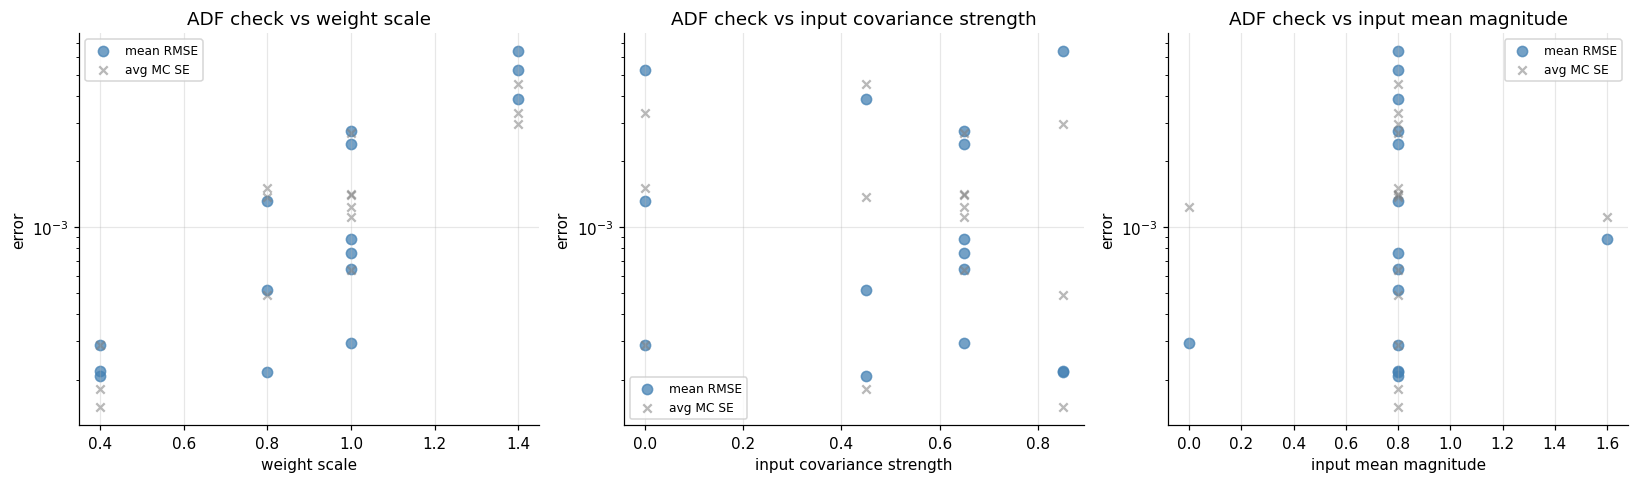

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, field, xlabel in [
    (axes[0], "weight_scale", "weight scale"),
    (axes[1], "corr_strength", "input covariance strength"),
    (axes[2], "mean_magnitude", "input mean magnitude"),
]:
    xs = np.array([getattr(r, field) for r in results])
    ys = np.array([r.mean_rmse for r in results])
    se = np.array([r.avg_mc_se for r in results])
    ax.scatter(xs, ys, s=45, alpha=0.75, color="steelblue", label="mean RMSE")
    ax.scatter(xs, se, s=30, alpha=0.55, color="gray", marker="x", label="avg MC SE")
    ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("error")
    ax.set_title(f"ADF check vs {xlabel}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Optional: Compare Full-Covariance ADF Against Diagonal ADF

For the exact architecture above, the output layer is linear. That means the output mean uses only the hidden mean, so full-covariance ADF and diagonal ADF give the same output expectation. The covariance still differs.

To show when full covariance matters for expected values, we also add a hypothetical ReLU on the output pre-activation. Then each output expectation depends on its pre-activation variance, and that variance depends on hidden-layer covariances.

In [12]:
mu1_diag, var1_diag, _ = relu_univariate_moments(mu_z1, np.diag(Sigma_z1))
Sigma1_diag = np.diag(var1_diag)
mu_out_diag, Sigma_out_diag = affine_gaussian_moments(mu1_diag, Sigma1_diag, W2, b2)

print("Linear output mean comparison")
print(f"  max |full ADF mean - diagonal ADF mean| = {np.max(np.abs(mu_out_adf - mu_out_diag)):.3e}")
print(f"  full-cov covariance relative error vs MC = {np.linalg.norm(Sigma_out_adf - mc['out_cov'], 'fro') / np.linalg.norm(mc['out_cov'], 'fro'):.3e}")
print(f"  diag-cov covariance relative error vs MC = {np.linalg.norm(Sigma_out_diag - mc['out_cov'], 'fro') / np.linalg.norm(mc['out_cov'], 'fro'):.3e}")

full_relu_out_mean, _, _ = relu_univariate_moments(mu_out_adf, np.diag(Sigma_out_adf))
diag_relu_out_mean, _, _ = relu_univariate_moments(mu_out_diag, np.diag(Sigma_out_diag))
mc_relu_out_mean = np.maximum(mc["out_mean"] + 0.0, 0.0)  # placeholder overwritten below
_, out_samples = exact_forward(
    np.random.default_rng(321).multivariate_normal(mu0, Sigma0, size=N_MC, method="svd"),
    W1,
    b1,
    W2,
    b2,
)
mc_relu_out_mean = np.maximum(out_samples, 0.0).mean(axis=0)

print("\nIf the output pre-activation also passed through ReLU")
for k in range(D2):
    print(f"  output {k}: MC={mc_relu_out_mean[k]:+.6f}  full={full_relu_out_mean[k]:+.6f}  diag={diag_relu_out_mean[k]:+.6f}")
print(f"  full ADF ReLU-output RMSE = {np.sqrt(np.mean((full_relu_out_mean - mc_relu_out_mean) ** 2)):.3e}")
print(f"  diag ADF ReLU-output RMSE = {np.sqrt(np.mean((diag_relu_out_mean - mc_relu_out_mean) ** 2)):.3e}")

Linear output mean comparison
  max |full ADF mean - diagonal ADF mean| = 0.000e+00
  full-cov covariance relative error vs MC = 1.360e-01
  diag-cov covariance relative error vs MC = 4.686e-01

If the output pre-activation also passed through ReLU
  output 0: MC=+0.185402  full=+0.183329  diag=+0.182567
  output 1: MC=+0.128058  full=+0.123962  diag=+0.136873
  output 2: MC=+0.043502  full=+0.047980  diag=+0.055294
  output 3: MC=+0.000105  full=+0.003937  diag=+0.000643
  full ADF ReLU-output RMSE = 3.736e-03
  diag ADF ReLU-output RMSE = 7.502e-03


## 12. WHest Mini Check: ADF-Style Propagation vs `final_means`

The toy 3-layer network isolates the math. The WHest networks in `sample_data_viz.ipynb` are deeper: 32 ReLU layers of width 256, no biases, and standard normal inputs. After the first ReLU layer, ADF repeatedly replaces a non-Gaussian activation distribution with a Gaussian, so approximation error can accumulate.

The full exact bivariate ReLU update for width 256 across 32 layers is expensive. For a practical notebook check, this section uses the common full-covariance **gain approximation** from the starter kit example: exact ReLU marginal means and variances, with off-diagonal covariance scaled by firing probabilities. The final comparison is against the dataset's `final_means` target.

In [13]:
def whest_diag_adf_predict(weights):
    width = weights.shape[1]
    mu = np.zeros(width, dtype=np.float64)
    var = np.ones(width, dtype=np.float64)
    rows = []
    for w in weights.astype(np.float64):
        mu_pre = w.T @ mu
        var_pre = (w * w).T @ var
        mu, var, _ = relu_univariate_moments(mu_pre, var_pre)
        rows.append(mu.copy())
    return np.stack(rows)


def whest_full_cov_gain_adf_predict(weights):
    width = weights.shape[1]
    mu = np.zeros(width, dtype=np.float64)
    cov = np.eye(width, dtype=np.float64)
    rows = []
    for w in weights.astype(np.float64):
        mu_pre = w.T @ mu
        cov_pre = symmetrize(w.T @ cov @ w)
        var_pre = np.maximum(np.diag(cov_pre), 1e-12)
        sigma_pre = np.sqrt(var_pre)
        alpha = mu_pre / sigma_pre
        Phi = norm.cdf(alpha)
        phi = norm.pdf(alpha)
        mu = mu_pre * Phi + sigma_pre * phi
        ez2 = (mu_pre * mu_pre + var_pre) * Phi + mu_pre * sigma_pre * phi
        var_post = np.maximum(ez2 - mu * mu, 0.0)
        gain = np.where(sigma_pre > 1e-12, Phi, 0.0)
        cov = np.outer(gain, gain) * cov_pre
        cov[np.diag_indices(width)] = var_post
        cov = symmetrize(cov)
        rows.append(mu.copy())
    return np.stack(rows)

if wb is None:
    raise ImportError("whestbench is not installed in this kernel. Run the notebook with the repo's uv/Jupyter environment.")

REPO = "aicrowd/arc-whestbench-public-2026"
REVISION = "v1-phase1"
SPLIT = "mini"

ds = wb.load_dataset(REPO, revision=REVISION, split=SPLIT)
names = ds["mlp_name"]
all_layer_means = np.asarray(ds["all_layer_means"], dtype=np.float64)
final_means = np.asarray(ds["final_means"], dtype=np.float64)
print(f"Loaded {len(ds)} MLPs; target shape: {final_means.shape}")

whestbench: downloading 'mini' split from hf://aicrowd/arc-whestbench-public-2026@v1-phase1
Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 61455.00it/s]


Loaded 100 MLPs; target shape: (100, 256)


In [14]:
WHest_IDS = [0]  # Add more IDs after the first run if the full-covariance pass is fast enough on your machine.
whest_results = []
whest_preds = {}

for mi in WHest_IDS:
    W = np.asarray(wb.mlp_at(ds, mi).weights, dtype=np.float64)
    pred_diag = whest_diag_adf_predict(W)
    pred_full = whest_full_cov_gain_adf_predict(W)
    truth_layers = all_layer_means[mi]
    truth_final = final_means[mi]

    row = {
        "mlp_id": mi,
        "name": names[mi],
        "diag_final_mse": float(np.mean((pred_diag[-1] - truth_final) ** 2)),
        "full_gain_final_mse": float(np.mean((pred_full[-1] - truth_final) ** 2)),
        "diag_all_layers_mse": float(np.mean((pred_diag - truth_layers) ** 2)),
        "full_gain_all_layers_mse": float(np.mean((pred_full - truth_layers) ** 2)),
    }
    whest_results.append(row)
    whest_preds[mi] = {"diag": pred_diag, "full_gain": pred_full}
    print(row)

print("\nSummary")
for key in ["diag_final_mse", "full_gain_final_mse", "diag_all_layers_mse", "full_gain_all_layers_mse"]:
    vals = np.array([r[key] for r in whest_results])
    print(f"  {key:26s}: mean={vals.mean():.4e}  min={vals.min():.4e}  max={vals.max():.4e}")

{'mlp_id': 0, 'name': 'daniel-harrison', 'diag_final_mse': 0.001894050760468252, 'full_gain_final_mse': 4.189526842969079e-05, 'diag_all_layers_mse': 0.0011130432302521726, 'full_gain_all_layers_mse': 3.4688292701106276e-05}

Summary
  diag_final_mse            : mean=1.8941e-03  min=1.8941e-03  max=1.8941e-03
  full_gain_final_mse       : mean=4.1895e-05  min=4.1895e-05  max=4.1895e-05
  diag_all_layers_mse       : mean=1.1130e-03  min=1.1130e-03  max=1.1130e-03
  full_gain_all_layers_mse  : mean=3.4688e-05  min=3.4688e-05  max=3.4688e-05


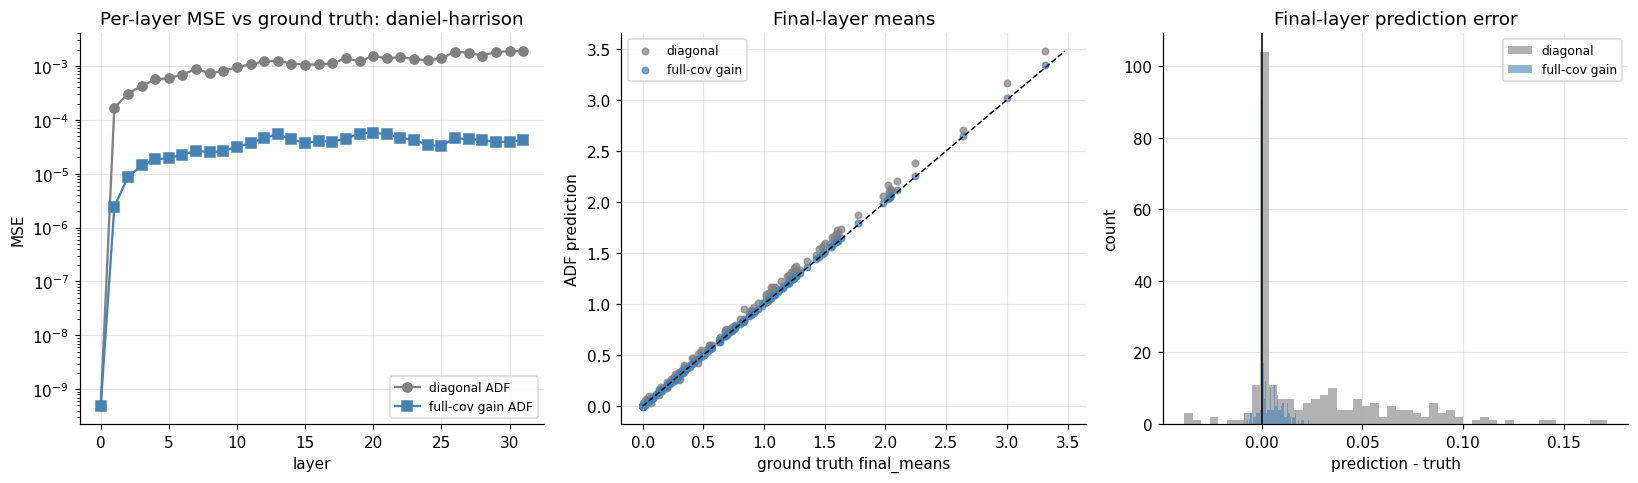

In [15]:
mi = WHest_IDS[0]
pred_diag = whest_preds[mi]["diag"]
pred_full = whest_preds[mi]["full_gain"]
truth = all_layer_means[mi]

layer_mse_diag = np.mean((pred_diag - truth) ** 2, axis=1)
layer_mse_full = np.mean((pred_full - truth) ** 2, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].semilogy(layer_mse_diag, "o-", color="gray", label="diagonal ADF")
axes[0].semilogy(layer_mse_full, "s-", color="steelblue", label="full-cov gain ADF")
axes[0].set(title=f"Per-layer MSE vs ground truth: {names[mi]}", xlabel="layer", ylabel="MSE")
axes[0].legend(fontsize=8)

axes[1].scatter(final_means[mi], pred_diag[-1], s=18, alpha=0.7, color="gray", label="diagonal")
axes[1].scatter(final_means[mi], pred_full[-1], s=18, alpha=0.7, color="steelblue", label="full-cov gain")
lo = min(final_means[mi].min(), pred_diag[-1].min(), pred_full[-1].min())
hi = max(final_means[mi].max(), pred_diag[-1].max(), pred_full[-1].max())
axes[1].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[1].set(title="Final-layer means", xlabel="ground truth final_means", ylabel="ADF prediction")
axes[1].legend(fontsize=8)

axes[2].hist(pred_diag[-1] - final_means[mi], bins=50, alpha=0.6, color="gray", label="diagonal")
axes[2].hist(pred_full[-1] - final_means[mi], bins=50, alpha=0.6, color="steelblue", label="full-cov gain")
axes[2].axvline(0, color="k", lw=1)
axes[2].set(title="Final-layer prediction error", xlabel="prediction - truth", ylabel="count")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 13. Paper and Author-Repo Algorithm: Analytic ReLU Covariance by Taylor Order

Wright, Nakahira, and Moura (2024), *An Analytic Solution to Covariance Propagation in Neural Networks*, gives a general covariance formula for elementwise activations under a Gaussian pre-activation assumption:

$$
\operatorname{Cov}(z_i,z_j)=\sum_{k=1}^{\infty}\frac{\rho_{ij}^k}{k!}
\left(\sigma_i^k\frac{\partial^k \mathbb{E}[z_i]}{\partial \mu_i^k}\right)
\left(\sigma_j^k\frac{\partial^k \mathbb{E}[z_j]}{\partial \mu_j^k}\right).
$$

I checked the authors' public repository, `omwright/cov-prop-nn`. The top-level experiment script `run_tightness_synthetic.py` implements the ReLU covariance with the first four Taylor terms (`t1` through `t4`). The bundled `network_moments` package also contains a zero-mean ReLU covariance kernel used for older PL-DNN-style comparisons, but the paper experiment path is the fourth-order series.

For ReLU, the first term is exactly the gain approximation used in `examples/03_covariance_propagation.py`:

$$
\operatorname{Cov}(\operatorname{ReLU}(y_i),\operatorname{ReLU}(y_j))
\approx \Phi(\alpha_i)\Phi(\alpha_j)\operatorname{Cov}(y_i,y_j).
$$

The cells below implement the truncated paper series. Order 1 should match the starter-kit gain method; order 4 matches the author repo's synthetic-experiment implementation.

In [19]:
import math


def probabilists_hermite(n, x):
    """Probabilists' Hermite polynomial He_n(x), vectorized."""
    x = np.asarray(x, dtype=np.float64)
    if n == 0:
        return np.ones_like(x)
    if n == 1:
        return x
    hm2 = np.ones_like(x)
    hm1 = x
    for k in range(1, n):
        h = x * hm1 - k * hm2
        hm2, hm1 = hm1, h
    return hm1


def relu_paper_series_terms(mu, var, order):
    """Return a_k = sigma^k d^k E[ReLU(y)] / dmu^k for k=1..order."""
    var = np.maximum(np.asarray(var, dtype=np.float64), 1e-12)
    sigma = np.sqrt(var)
    alpha = np.asarray(mu, dtype=np.float64) / sigma
    Phi = norm.cdf(alpha)
    phi = norm.pdf(alpha)

    terms = [sigma * Phi]
    for k in range(2, order + 1):
        terms.append(sigma * ((-1.0) ** k) * probabilists_hermite(k - 2, alpha) * phi)
    return terms


def relu_adf_paper_series_moments(mu_z, Sigma_z, order=4):
    """ReLU moment matching using the paper's truncated covariance series."""
    mu_z = np.asarray(mu_z, dtype=np.float64)
    Sigma_z = symmetrize(np.asarray(Sigma_z, dtype=np.float64))
    var_z = np.maximum(np.diag(Sigma_z), 1e-12)
    sigma = np.sqrt(var_z)
    denom = np.outer(sigma, sigma)
    rho = np.divide(Sigma_z, denom, out=np.zeros_like(Sigma_z), where=denom > 0)
    rho = np.clip(rho, -0.999999, 0.999999)

    mu_relu, var_relu, _ = relu_univariate_moments(mu_z, var_z)
    cov_relu = np.zeros_like(Sigma_z)
    for k, term in enumerate(relu_paper_series_terms(mu_z, var_z, order), start=1):
        cov_relu += (rho ** k / math.factorial(k)) * np.outer(term, term)

    cov_relu = symmetrize(cov_relu)
    cov_relu[np.diag_indices_from(cov_relu)] = var_relu
    return mu_relu, cov_relu


def relu_adf_gain_moments(mu_z, Sigma_z):
    """Starter-kit gain covariance update: the paper series truncated at order 1."""
    return relu_adf_paper_series_moments(mu_z, Sigma_z, order=1)

## 14. Toy Comparison: Gain vs Paper Series vs Exact Pairwise ADF

On the one-hidden-layer toy network, all methods use the same exact ReLU marginal mean. Therefore the linear output mean is the same. The differences appear in covariance, and they become visible in the expected value if the next layer applies another ReLU.

In [20]:
toy_methods = {}

# Starter-kit gain approximation: equivalent to paper order 1 for off-diagonal covariance.
mu1_gain, Sigma1_gain = relu_adf_gain_moments(mu_z1, Sigma_z1)
toy_methods["gain / paper K=1"] = affine_gaussian_moments(mu1_gain, Sigma1_gain, W2, b2)

for order in [2, 4, 8]:
    mu1_k, Sigma1_k = relu_adf_paper_series_moments(mu_z1, Sigma_z1, order=order)
    toy_methods[f"paper K={order}"] = affine_gaussian_moments(mu1_k, Sigma1_k, W2, b2)

toy_methods["exact pairwise ADF"] = (mu_out_adf, Sigma_out_adf)

print("Toy 3-layer network: linear output")
print("method                 mean_RMSE_vs_MC   cov_rel_F_vs_MC   relu_output_mean_RMSE")
for name, (mu_y, Sigma_y) in toy_methods.items():
    mean_rmse = np.sqrt(np.mean((mu_y - mc["out_mean"]) ** 2))
    cov_rel = np.linalg.norm(Sigma_y - mc["out_cov"], ord="fro") / np.linalg.norm(mc["out_cov"], ord="fro")
    relu_y_mean, _, _ = relu_univariate_moments(mu_y, np.diag(Sigma_y))
    relu_rmse = np.sqrt(np.mean((relu_y_mean - mc_relu_out_mean) ** 2))
    print(f"{name:22s} {mean_rmse:15.3e} {cov_rel:17.3e} {relu_rmse:22.3e}")

Sigma_gain = toy_methods["gain / paper K=1"][1]
Sigma_k1 = affine_gaussian_moments(
    *relu_adf_paper_series_moments(mu_z1, Sigma_z1, order=1),
    W2,
    b2,
)[1]
print(f"\nmax |starter gain covariance - paper K=1 covariance| = {np.max(np.abs(Sigma_gain - Sigma_k1)):.3e}")

Toy 3-layer network: linear output
method                 mean_RMSE_vs_MC   cov_rel_F_vs_MC   relu_output_mean_RMSE
gain / paper K=1             6.698e-04         5.821e-02              4.805e-03
paper K=2                    6.698e-04         5.264e-03              3.927e-03
paper K=4                    6.698e-04         4.113e-03              3.929e-03
paper K=8                    6.698e-04         4.055e-03              3.925e-03
exact pairwise ADF           6.698e-04         1.360e-01              3.736e-03

max |starter gain covariance - paper K=1 covariance| = 0.000e+00


## 15. WHest Comparison: Starter Gain vs Paper-Series Covariance Propagation

For the WHest networks, the paper-series update can replace the starter-kit gain update inside the full-covariance propagation loop. `paper K=1` should match the starter-kit gain method, while larger `K` values add higher-order covariance corrections.

The default below runs one MLP and two paper orders. Increase `WHest_IDS` or `PAPER_ORDERS` after a first run if the runtime is acceptable.

In [24]:
def whest_paper_series_cov_adf_predict(weights, order=4, rescale_threshold=1e100):
    """Full-covariance WHest propagation with the paper's truncated ReLU covariance series."""
    width = weights.shape[1]
    mu = np.zeros(width, dtype=np.float64)
    cov = np.eye(width, dtype=np.float64)
    log_scale = 0.0
    rows = []

    for w in weights.astype(np.float64):
        max_var = float(np.max(np.diag(cov)))
        if max_var > rescale_threshold:
            scale = float(np.sqrt(max_var))
            mu = mu / scale
            cov = cov / (scale * scale)
            log_scale += float(np.log(scale))

        mu_pre = w.T @ mu
        cov_pre = symmetrize(w.T @ cov @ w)
        mu, cov = relu_adf_paper_series_moments(mu_pre, cov_pre, order=order)
        rows.append(mu * float(np.exp(log_scale)))

    return np.stack(rows)

In [25]:
PAPER_ORDERS = [1, 4]
paper_whest_preds = {}
comparison_rows = []

for mi in WHest_IDS:
    W = np.asarray(wb.mlp_at(ds, mi).weights, dtype=np.float64)
    truth_layers = all_layer_means[mi]
    truth_final = final_means[mi]

    methods = {
        "diagonal ADF": whest_preds[mi]["diag"],
        "starter gain": whest_preds[mi]["full_gain"],
    }
    for order in PAPER_ORDERS:
        pred = whest_paper_series_cov_adf_predict(W, order=order)
        methods[f"paper K={order}"] = pred
        paper_whest_preds[(mi, order)] = pred

    for name, pred in methods.items():
        comparison_rows.append({
            "mlp_id": mi,
            "method": name,
            "final_mse": float(np.mean((pred[-1] - truth_final) ** 2)),
            "all_layers_mse": float(np.mean((pred - truth_layers) ** 2)),
            "final_mae": float(np.mean(np.abs(pred[-1] - truth_final))),
        })

print("mlp  method          final_mse    all_layers_mse  final_mae")
for row in comparison_rows:
    print(f"{row['mlp_id']:>3}  {row['method']:<14s}  {row['final_mse']:10.3e}  "
          f"{row['all_layers_mse']:14.3e}  {row['final_mae']:9.3e}")

if (WHest_IDS[0], 1) in paper_whest_preds:
    diff = np.max(np.abs(paper_whest_preds[(WHest_IDS[0], 1)] - whest_preds[WHest_IDS[0]]["full_gain"]))
    print(f"\nmax |starter gain - paper K=1| on MLP {WHest_IDS[0]} = {diff:.3e}")

mlp  method          final_mse    all_layers_mse  final_mae
  0  diagonal ADF     1.894e-03       1.113e-03  2.623e-02
  0  starter gain     4.190e-05       3.469e-05  4.103e-03
  0  paper K=1        4.190e-05       3.469e-05  4.103e-03
  0  paper K=4        3.579e-05       3.031e-05  3.818e-03

max |starter gain - paper K=1| on MLP 0 = 5.329e-15


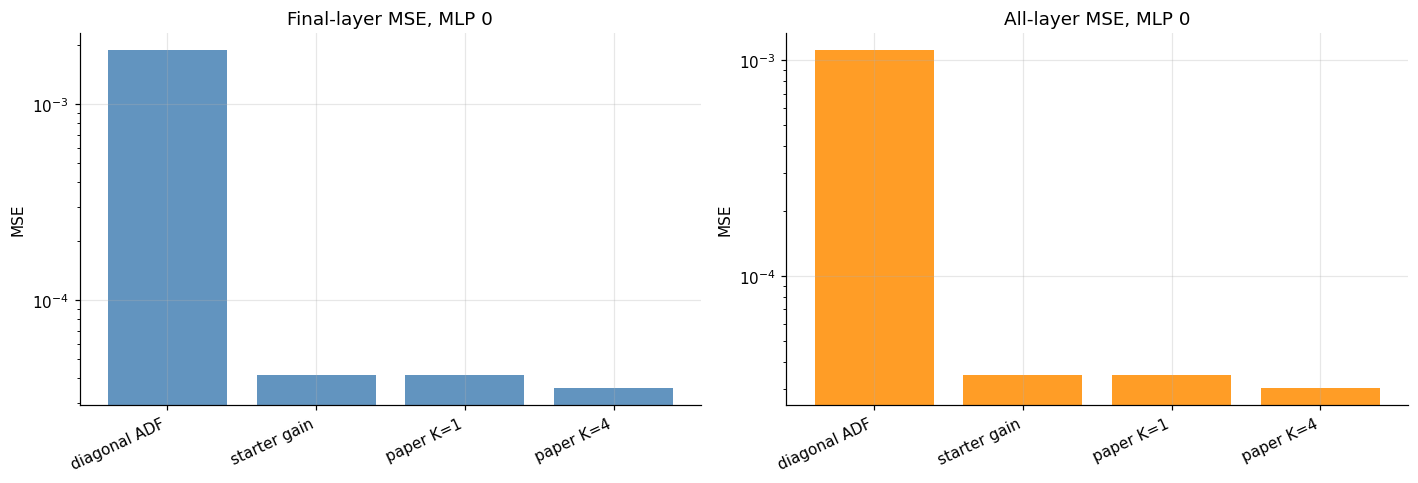

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = [row["method"] for row in comparison_rows if row["mlp_id"] == WHest_IDS[0]]
final_mse = [row["final_mse"] for row in comparison_rows if row["mlp_id"] == WHest_IDS[0]]
all_mse = [row["all_layers_mse"] for row in comparison_rows if row["mlp_id"] == WHest_IDS[0]]

xpos = np.arange(len(labels))
axes[0].bar(xpos, final_mse, color="steelblue", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_xticks(xpos, labels, rotation=25, ha="right")
axes[0].set(title=f"Final-layer MSE, MLP {WHest_IDS[0]}", ylabel="MSE")

axes[1].bar(xpos, all_mse, color="darkorange", alpha=0.85)
axes[1].set_yscale("log")
axes[1].set_xticks(xpos, labels, rotation=25, ha="right")
axes[1].set(title=f"All-layer MSE, MLP {WHest_IDS[0]}", ylabel="MSE")

plt.tight_layout()
plt.show()

## Takeaways

- In the 3-layer Gaussian-input, ReLU-hidden, linear-output case, full-covariance ADF should match Monte Carlo output means and covariances up to sampling error.
- Diagonal ADF gives the same linear-output mean in this one-hidden-layer setup, but it loses output covariance accuracy.
- Once another ReLU or another hidden layer is applied, covariance affects downstream expected activations, so full-covariance tracking can improve the expected output.
- For the 32-layer WHest networks, repeated Gaussian moment matching is approximate; the final `final_means` comparison measures the accumulated approximation error against the benchmark target.